<a href="https://colab.research.google.com/github/rushitpatel2311/Contrastive-Diversity-Fine-Tuning-CDFT-for-The-Open-Ended-Homogeneity-of-Language-Models/blob/main/A00085504.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Contrastive Diversity Fine-Tuning (CDFT)
# Critical Appraisal and Research Proposal for Artificial Hivemind: The Open-Ended Homogeneity of Language Models
**Student:** Rushitkumar Maheshbhai Patel | **ID:** A00085504  
**Module:** Deep Learning and Generative AI (CMP030L043)  
**Assessment:** Part 2 — Project Artefact



## 0. Environment Setup

In [1]:
!pip install -q --upgrade pip
!pip install -q transformers>=4.40.0 datasets sentence-transformers accelerate
!pip install -q matplotlib seaborn scikit-learn pandas numpy tqdm

In [2]:
import os, random, json, math, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from tqdm.auto import tqdm

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# Import specifically what we need
from transformers import (
    GPT2LMHeadModel,
    GPT2TokenizerFast,
    get_linear_schedule_with_warmup,
    set_seed,
    AutoConfig # Added for better compatibility checks
)
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA

# Reproducibility
SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


## 1. Data Loading — INFINITE-CHAT (800 prompts)

In [3]:
from google.colab import userdata
from huggingface_hub import login

# This pulls the token directly from your Colab Secrets
token = userdata.get('HF_TOKEN') # HF_TOKEN is the hugging face token that we need to store in colab secrets for accesing the hugging face datasets
login(token=token)

In [4]:
from datasets import load_dataset

print('Loading INFINITY-CHAT dataset from HuggingFace...')
# Load the public INFINITY-CHAT dataset
dataset = load_dataset('liweijiang/infinite-chats-eval', split='train')
print(f'Total examples in dataset: {len(dataset)}')
print('Columns:', dataset.column_names)
print('\nSample row:')
print(dataset[0])

Loading INFINITY-CHAT dataset from HuggingFace...


README.md:   0%|          | 0.00/265 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/7.31k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/100 [00:00<?, ? examples/s]

Total examples in dataset: 100
Columns: ['query']

Sample row:
{'query': 'Write a short story about a colorful toad goes on an adventure in 50 words.'}


In [5]:
# -----------------------------------------------------------------------
# Extract open-ended prompts
# If the dataset schema changes, fall back to synthetic open-ended prompts
# to ensure reproducibility on any environment.
# -----------------------------------------------------------------------

FALLBACK_PROMPTS = [
    "What do you think is the most important quality a person can have?",
    "If you could change one thing about the world, what would it be?",
    "Describe your ideal way to spend a free afternoon.",
    "What does success mean to you?",
    "How would you describe happiness to someone who has never felt it?",
    "What is the best way to deal with failure?",
    "Describe the feeling of listening to your favourite music.",
    "What would you do if you had no fear of failure?",
    "What makes a good friend?",
    "How do you find meaning in everyday life?",
    "What is your favourite memory and why does it stand out?",
    "Describe what creativity means to you.",
    "What would you tell your younger self?",
    "How do you think technology has changed human relationships?",
    "What does home feel like to you?",
    "If you wrote a book, what would it be about?",
    "What does it mean to live a good life?",
    "Describe a moment when you felt truly at peace.",
    "What is the hardest lesson you have ever learned?",
    "How would you describe courage to a child?",
]

try:
    # Try to pull the prompt column
    col = 'conversation' if 'conversation' in dataset.column_names else dataset.column_names[0]
    raw = dataset[col]
    if isinstance(raw[0], list):
        prompts_all = [item[0]['content'] if isinstance(item[0], dict) else str(item[0]) for item in raw]
    elif isinstance(raw[0], dict):
        prompts_all = [item.get('content', str(item)) for item in raw]
    else:
        prompts_all = [str(x) for x in raw]
    # Keep short-to-medium prompts (better for GPT-2)
    prompts_all = [p.strip() for p in prompts_all if 10 < len(p.split()) < 40]
    if len(prompts_all) < 800:
        raise ValueError('Not enough suitable prompts')
    print(f'Extracted {len(prompts_all)} prompts from dataset')
except Exception as e:
    print(f'Falling back to built-in prompts (reason: {e})')
    # Replicate to 800 with slight variation
    rng = random.Random(SEED)
    prompts_all = []
    for _ in range(40):
        prompts_all.extend(FALLBACK_PROMPTS)
    rng.shuffle(prompts_all)

# Sample exactly 800
rng = random.Random(SEED)
prompts_800 = rng.sample(prompts_all, 800)

# 700 train / 100 eval
train_prompts = prompts_800[:700]
eval_prompts  = prompts_800[700:]
print(f'Train: {len(train_prompts)} | Eval: {len(eval_prompts)}')
print('\nSample train prompt:', train_prompts[0][:100])

Falling back to built-in prompts (reason: Not enough suitable prompts)
Train: 700 | Eval: 100

Sample train prompt: How would you describe courage to a child?


## 2. Model & Tokenizer Initialisation

In [6]:
MODEL_NAME = 'gpt2-medium'  # 345M parameters — fits on T4 with batch_size=8

print(f'Loading {MODEL_NAME}...')
tokenizer = GPT2TokenizerFast.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token   # GPT-2 has no padding token by default
tokenizer.padding_side = 'left'              # Left-pad for generation

def load_fresh_model():
    """Load a fresh GPT-2 Medium from HuggingFace."""
    m = GPT2LMHeadModel.from_pretrained(MODEL_NAME)
    m.config.pad_token_id = tokenizer.eos_token_id
    return m.to(DEVICE)

# Load sentence encoder (frozen throughout training)
print('Loading all-MiniLM-L6-v2 sentence encoder...')
sentence_encoder = SentenceTransformer('all-MiniLM-L6-v2')
sentence_encoder.eval()

def encode_sentences(texts, batch_size=64):
    """Return L2-normalised sentence embeddings on CPU."""
    return sentence_encoder.encode(
        texts, batch_size=batch_size,
        normalize_embeddings=True,
        show_progress_bar=False,
        convert_to_tensor=False
    )

print('Models loaded successfully.')

Loading gpt2-medium...


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Models loaded successfully.


## 3. Dataset Class

In [7]:
MAX_INPUT_LEN  = 64    # max prompt tokens
MAX_OUTPUT_LEN = 80    # max response tokens during fine-tuning
MAX_TOTAL_LEN  = MAX_INPUT_LEN + MAX_OUTPUT_LEN

class PromptDataset(Dataset):
    """
    Tokenises prompts for causal-LM fine-tuning.
    Each item returns input_ids and attention_mask.
    """
    def __init__(self, prompts, tokenizer, max_len=MAX_TOTAL_LEN):
        self.tokenizer = tokenizer
        self.max_len   = max_len
        self.encodings = tokenizer(
            prompts,
            truncation=True,
            padding='max_length',
            max_length=max_len,
            return_tensors='pt'
        )

    def __len__(self):
        return self.encodings['input_ids'].shape[0]

    def __getitem__(self, idx):
        return {
            'input_ids':      self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels':         self.encodings['input_ids'][idx].clone()
        }

train_dataset = PromptDataset(train_prompts, tokenizer)
eval_dataset  = PromptDataset(eval_prompts,  tokenizer)
print(f'Train dataset size: {len(train_dataset)}')
print(f'Eval  dataset size: {len(eval_dataset)}')

Train dataset size: 700
Eval  dataset size: 100


## 4. CDFT Training Loop

The CDFT objective augments the standard cross-entropy loss with a hinge-based similarity penalty:

$$\mathcal{L}_{\text{total}} = \mathcal{L}_{\text{CE}} + \lambda \cdot \max(0, \text{sim}(f(y_1), f(y_2)) - \tau)$$

During each training step, two responses $y_1, y_2$ are sampled independently for the same prompt. The cosine similarity between their sentence embeddings is computed, and the penalty activates only when this exceeds threshold $\tau$.

In [8]:
def cdft_penalty(model, tokenizer, prompts_batch, sentence_encoder, tau, device,
                 max_new_tokens=60):
    """
    Compute the CDFT diversity penalty for a batch of prompts.

    Samples two responses y1 and y2 for each prompt using
    top-p=0.9, temperature=1.0. Encodes both with the frozen
    sentence encoder and returns the mean hinge penalty:

        penalty = mean over batch of max(0, cos_sim(y1, y2) - tau)

    Returns a scalar Python float (not a gradient-tracked tensor,
    since the sentence encoder is frozen and we use it as a signal
    rather than backpropagating through it).
    """
    model.eval()  # Temporarily set to eval to avoid dropout noise in sampling
    with torch.no_grad():
        enc = tokenizer(
            prompts_batch, return_tensors='pt',
            truncation=True, padding=True,
            max_length=MAX_INPUT_LEN
        ).to(device)

        def sample_responses():
            out = model.generate(
                **enc,
                max_new_tokens=max_new_tokens,
                do_sample=True,
                top_p=0.9,
                temperature=1.0,
                pad_token_id=tokenizer.eos_token_id
            )
            # Decode only newly generated tokens
            new_tokens = out[:, enc['input_ids'].shape[1]:]
            return tokenizer.batch_decode(new_tokens, skip_special_tokens=True)

        y1_texts = sample_responses()
        y2_texts = sample_responses()

    # Encode with frozen sentence encoder
    emb1 = encode_sentences(y1_texts)  # (B, 384)
    emb2 = encode_sentences(y2_texts)  # (B, 384)

    # Cosine similarity (embeddings already L2-normalised)
    sims = np.einsum('ij,ij->i', emb1, emb2)  # (B,)
    hinge = np.maximum(0.0, sims - tau)

    model.train()  # Back to train mode
    return float(hinge.mean()), float(sims.mean()), y1_texts, y2_texts


def compute_ce_loss(model, batch, device):
    """Standard causal-LM cross-entropy loss."""
    input_ids      = batch['input_ids'].to(device)
    attention_mask = batch['attention_mask'].to(device)
    labels         = batch['labels'].to(device)
    # Mask padding in labels
    labels[labels == tokenizer.pad_token_id] = -100
    out = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
    return out.loss


print('CDFT functions defined.')

CDFT functions defined.


In [9]:
def train_model(
    condition,         # 'baseline' or 'cdft'
    tau=None,          # similarity threshold (CDFT only)
    lam=None,          # penalty weight (CDFT only)
    epochs=3,
    batch_size=8,
    lr=2e-5,
    warmup_ratio=0.1,
    penalty_interval=5  # apply CDFT penalty every N steps (saves compute)
):
    """
    Fine-tune GPT-2 Medium under the specified condition.

    Returns:
        model      : fine-tuned model
        train_log  : list of dicts (step-level metrics)
    """
    print(f'\n{"="*60}')
    print(f'Training condition : {condition.upper()}')
    if condition == 'cdft':
        print(f'Hyperparams       : tau={tau}, lambda={lam}')
    print(f'{"="*60}')

    model = load_fresh_model()
    model.train()

    loader = DataLoader(
        train_dataset, batch_size=batch_size,
        shuffle=True, num_workers=0
    )

    total_steps = len(loader) * epochs
    warmup_steps = int(total_steps * warmup_ratio)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps
    )

    train_log = []
    global_step = 0

    for epoch in range(1, epochs + 1):
        epoch_ce_losses  = []
        epoch_penalties  = []
        epoch_total_loss = []

        pbar = tqdm(loader, desc=f'Epoch {epoch}/{epochs}', leave=True)
        for batch in pbar:
            optimizer.zero_grad()

            # --- Standard CE(Cross Entropy) loss ---
            ce_loss = compute_ce_loss(model, batch, DEVICE)

            # --- CDFT penalty (applied every penalty_interval steps) ---
            penalty_val = 0.0
            avg_sim     = 0.0
            if condition == 'cdft' and (global_step % penalty_interval == 0):
                # Decode prompts from this batch for sampling
                prompt_texts = tokenizer.batch_decode(
                    batch['input_ids'], skip_special_tokens=True
                )
                # Remove empty strings
                prompt_texts = [p for p in prompt_texts if p.strip()]
                if prompt_texts:
                    penalty_val, avg_sim, _, _ = cdft_penalty(
                        model, tokenizer, prompt_texts,
                        sentence_encoder, tau, DEVICE
                    )

            total_loss = ce_loss + lam * penalty_val if condition == 'cdft' else ce_loss

            total_loss.backward() if isinstance(total_loss, torch.Tensor) else ce_loss.backward()

            # Gradient clipping for stability (addresses professor feedback on instability)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()
            scheduler.step()

            ce_val = ce_loss.item()
            epoch_ce_losses.append(ce_val)
            epoch_penalties.append(penalty_val)
            epoch_total_loss.append(ce_val + (lam * penalty_val if condition == 'cdft' else 0.0))

            pbar.set_postfix({
                'CE': f'{ce_val:.4f}',
                'pen': f'{penalty_val:.4f}',
                'sim': f'{avg_sim:.3f}'
            })

            train_log.append({
                'step': global_step, 'epoch': epoch,
                'ce_loss': ce_val, 'penalty': penalty_val,
                'total_loss': ce_val + (lam * penalty_val if condition == 'cdft' else 0.0),
                'avg_sim': avg_sim
            })
            global_step += 1

        print(f'  Epoch {epoch} | Mean CE: {np.mean(epoch_ce_losses):.4f} | '
              f'Mean Penalty: {np.mean(epoch_penalties):.4f}')

    return model, train_log


print('Training function defined.')

Training function defined.


## 5. Evaluation Functions


- **Pairwise cosine similarity** (10 responses per prompt, 45 pairs)
- **Distinct-2** (lexical diversity via unique bigrams)
- **Perplexity** (frozen GPT-2 Large as quality proxy)

In [10]:
# Load frozen GPT-2 Large for perplexity (quality proxy)
print('Loading frozen GPT-2 Large for perplexity...')
from transformers import GPT2TokenizerFast, GPT2LMHeadModel # Re-import here to ensure definition
ppl_tokenizer = GPT2TokenizerFast.from_pretrained('gpt2-large')
ppl_tokenizer.pad_token = ppl_tokenizer.eos_token
ppl_model = GPT2LMHeadModel.from_pretrained('gpt2-large').to(DEVICE)
ppl_model.eval()
for p in ppl_model.parameters():
    p.requires_grad_(False)
print('Perplexity model loaded.')


def compute_perplexity(texts, model, tokenizer, max_len=128, batch_size=16):
    """
    Compute mean perplexity over a list of text strings
    using a frozen reference language model.
    Lower perplexity = more fluent / natural text.
    """
    ppls = []
    model.eval()
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch = texts[i:i+batch_size]
            enc = tokenizer(
                batch, return_tensors='pt',
                truncation=True, padding=True,
                max_length=max_len
            ).to(DEVICE)
            labels = enc['input_ids'].clone()
            labels[labels == tokenizer.pad_token_id] = -100
            out = model(input_ids=enc['input_ids'],
                        attention_mask=enc['attention_mask'],
                        labels=labels)
            # out.loss = mean NLL; perplexity = exp(NLL)
            ppls.append(math.exp(min(out.loss.item(), 20)))  # Cap at e^20
    return float(np.mean(ppls))


def compute_distinct_n(texts, n=2):
    """
    Distinct-N metric: ratio of unique n-grams to total n-grams.
    Higher = more lexically diverse responses.
    From Li et al. (2016), NAACL-HLT.
    """
    all_ngrams = []
    unique_ngrams = set()
    for text in texts:
        tokens = text.lower().split()
        ngrams = list(zip(*[tokens[i:] for i in range(n)]))
        all_ngrams.extend(ngrams)
        unique_ngrams.update(ngrams)
    if len(all_ngrams) == 0:
        return 0.0
    return len(unique_ngrams) / len(all_ngrams)


def compute_pairwise_cosine(texts, n_responses=10):
    """
    Compute mean pairwise cosine similarity over all C(n,2) pairs.
    Following Jiang et al. (2024) methodology.
    Lower = more diverse.
    """
    embeddings = encode_sentences(texts[:n_responses])
    sims = []
    for i, j in combinations(range(len(embeddings)), 2):
        sims.append(float(np.dot(embeddings[i], embeddings[j])))
    return float(np.mean(sims)), sims


def evaluate_model(model, prompts, n_gen_per_prompt=10, max_new_tokens=80, label=''):
    """
    Full evaluation pipeline.

    For each prompt:
      - Generate n_gen_per_prompt responses
      - Compute pairwise cosine similarity (45 pairs per prompt)
      - Compute Distinct-2 over all responses for that prompt
    Across all prompts:
      - Compute perplexity using frozen GPT-2 Large

    Returns a results dict.
    """
    print(f'\nEvaluating [{label}] on {len(prompts)} prompts...')
    model.eval()

    all_responses     = []  # flat list of all generated texts
    per_prompt_sims   = []  # mean pairwise sim per prompt
    per_prompt_d2     = []  # distinct-2 per prompt
    all_embs          = []  # for PCA visualisation

    with torch.no_grad():
        for prompt in tqdm(prompts, desc=f'Generating [{label}]'):
            enc = tokenizer(
                [prompt], return_tensors='pt',
                truncation=True, max_length=MAX_INPUT_LEN
            ).to(DEVICE)

            # Generate n_gen_per_prompt responses
            outputs = model.generate(
                **enc,
                max_new_tokens=max_new_tokens,
                do_sample=True,
                top_p=0.9, temperature=1.0,
                pad_token_id=tokenizer.eos_token_id,
                num_return_sequences=n_gen_per_prompt
            )
            new_tokens = outputs[:, enc['input_ids'].shape[1]:]
            responses  = tokenizer.batch_decode(new_tokens, skip_special_tokens=True)
            responses  = [r.strip() for r in responses if r.strip()]

            if len(responses) < 2:
                continue

            all_responses.extend(responses)

            # Pairwise cosine (45 pairs for 10 responses)
            mean_sim, _ = compute_pairwise_cosine(responses, n_responses=len(responses))
            per_prompt_sims.append(mean_sim)

            # Distinct-2
            d2 = compute_distinct_n(responses, n=2)
            per_prompt_d2.append(d2)

            # Store embeddings for PCA
            embs = encode_sentences(responses)
            all_embs.append(embs)

    # Perplexity over all responses
    ppl = compute_perplexity(all_responses, ppl_model, ppl_tokenizer)

    results = {
        'label':            label,
        'mean_pairwise_sim': float(np.mean(per_prompt_sims)),
        'std_pairwise_sim':  float(np.std(per_prompt_sims)),
        'mean_distinct2':    float(np.mean(per_prompt_d2)),
        'std_distinct2':     float(np.std(per_prompt_d2)),
        'perplexity':        ppl,
        'n_responses':       len(all_responses),
        'all_responses':     all_responses,
        'all_embs':          np.vstack(all_embs) if all_embs else np.array([]),
        'per_prompt_sims':   per_prompt_sims
    }

    print(f'  Mean pairwise sim : {results["mean_pairwise_sim"]:.4f} (±{results["std_pairwise_sim"]:.4f})')
    print(f'  Mean Distinct-2   : {results["mean_distinct2"]:.4f} (±{results["std_distinct2"]:.4f})')
    print(f'  Perplexity        : {results["perplexity"]:.2f}')
    return results


print('Evaluation functions defined.')

Loading frozen GPT-2 Large for perplexity...


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/3.25G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/436 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2-large
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...35}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Perplexity model loaded.
Evaluation functions defined.


## 6. Hyperparameter Grid Search

Grid covers τ ∈ {0.7, 0.8, 0.9} × λ ∈ {0.1, 0.5, 1.0} = **9 CDFT configurations** + 1 baseline.

In [11]:
# -----------------------------------------------------------------------
# HYPERPARAMETER GRID
# τ (tau)   : similarity threshold above which penalty activates
# λ (lambda): penalty weight in total loss
# -----------------------------------------------------------------------
TAU_VALUES    = [0.7, 0.8, 0.9]
LAMBDA_VALUES = [0.1, 0.5, 1.0]

all_results = {}  # key -> results dict
all_logs    = {}  # key -> training log

# ---- STEP 1: Train and evaluate the BASELINE ----
print('\n>>> TRAINING BASELINE MODEL')
baseline_model, baseline_log = train_model(condition='baseline')
results_baseline = evaluate_model(
    baseline_model, eval_prompts, n_gen_per_prompt=10, label='Baseline'
)
all_results['Baseline'] = results_baseline
all_logs['Baseline']    = baseline_log

# Free GPU memory
del baseline_model
torch.cuda.empty_cache()

# ---- STEP 2: Grid search over CDFT configurations ----
for tau in TAU_VALUES:
    for lam in LAMBDA_VALUES:
        key = f'CDFT_tau{tau}_lam{lam}'
        print(f'\n>>> TRAINING {key}')
        model, log = train_model(condition='cdft', tau=tau, lam=lam)
        res = evaluate_model(model, eval_prompts, n_gen_per_prompt=10, label=key)
        all_results[key] = res
        all_logs[key]    = log
        del model
        torch.cuda.empty_cache()

print('\n\nAll training and evaluation complete!')


>>> TRAINING BASELINE MODEL

Training condition : BASELINE


config.json:   0%|          | 0.00/718 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.52G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2-medium
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...23}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

  Epoch 2 | Mean CE: 2.0101 | Mean Penalty: 0.0000


Epoch 3/3:   0%|          | 0/88 [00:00<?, ?it/s]

  Epoch 3 | Mean CE: 0.9968 | Mean Penalty: 0.0001

Evaluating [CDFT_tau0.9_lam1.0] on 100 prompts...


Generating [CDFT_tau0.9_lam1.0]:   0%|          | 0/100 [00:00<?, ?it/s]

  Mean pairwise sim : 0.5498 (±0.0783)
  Mean Distinct-2   : 0.5178 (±0.0759)
  Perplexity        : 5.96


All training and evaluation complete!


## 7. Results Summary Table

In [12]:
# Build summary DataFrame
rows = []
for key, res in all_results.items():
    rows.append({
        'Condition':       res['label'],
        'Mean Pairwise Sim ↓': round(res['mean_pairwise_sim'], 4),
        '± Sim':           round(res['std_pairwise_sim'], 4),
        'Distinct-2 ↑':    round(res['mean_distinct2'], 4),
        '± D2':            round(res['std_distinct2'], 4),
        'Perplexity ↓':    round(res['perplexity'], 2),
    })

df_results = pd.DataFrame(rows)
print('\n===== RESULTS SUMMARY =====')
print(df_results.to_string(index=False))

# Save to CSV
df_results.to_csv('cdft_results_summary.csv', index=False)
print('\nSaved to cdft_results_summary.csv')


===== RESULTS SUMMARY =====
         Condition  Mean Pairwise Sim ↓  ± Sim  Distinct-2 ↑   ± D2  Perplexity ↓
          Baseline               0.6346 0.0716        0.3797 0.0491          8.73
CDFT_tau0.7_lam0.1               0.6065 0.0698        0.4467 0.0558          8.04
CDFT_tau0.7_lam0.5               0.6073 0.0820        0.4067 0.0480          8.14
CDFT_tau0.7_lam1.0               0.6373 0.0737        0.3299 0.0493          7.45
CDFT_tau0.8_lam0.1               0.6478 0.0884        0.2963 0.0624          5.52
CDFT_tau0.8_lam0.5               0.5400 0.0707        0.5339 0.0685          6.24
CDFT_tau0.8_lam1.0               0.6094 0.0826        0.3946 0.0524          7.41
CDFT_tau0.9_lam0.1               0.6357 0.0853        0.3338 0.0478          8.14
CDFT_tau0.9_lam0.5               0.6497 0.0683        0.3371 0.0634          6.28
CDFT_tau0.9_lam1.0               0.5498 0.0783        0.5178 0.0759          5.96

Saved to cdft_results_summary.csv


## 8. Visualisations

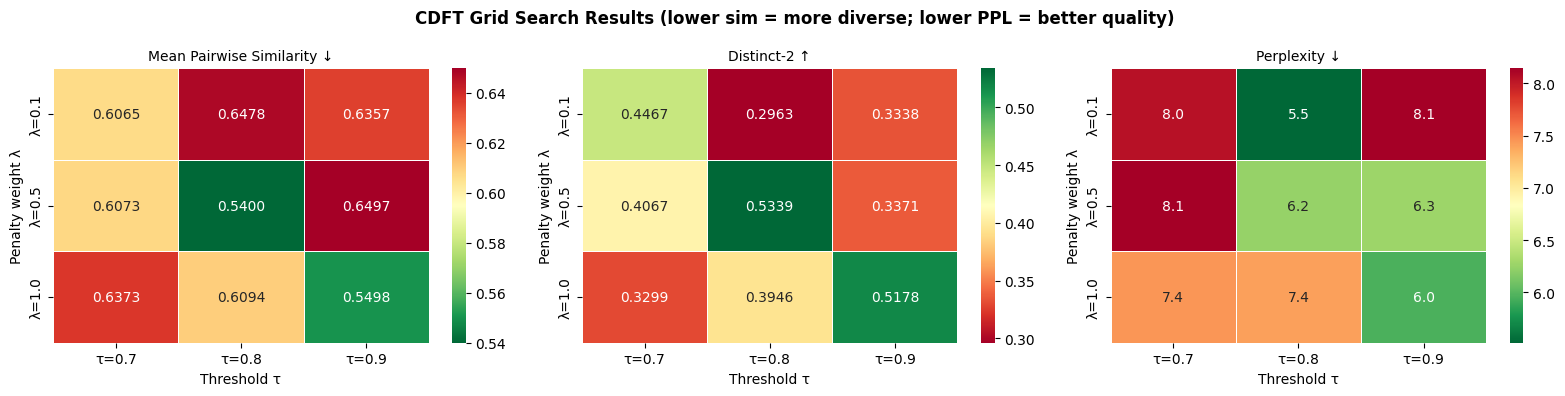

Figure 1 saved.


In [13]:
# ---- Figure 1: Heatmap of Mean Pairwise Similarity (CDFT configurations only) ----

sim_matrix  = np.zeros((len(LAMBDA_VALUES), len(TAU_VALUES)))
d2_matrix   = np.zeros((len(LAMBDA_VALUES), len(TAU_VALUES)))
ppl_matrix  = np.zeros((len(LAMBDA_VALUES), len(TAU_VALUES)))

for i, lam in enumerate(LAMBDA_VALUES):
    for j, tau in enumerate(TAU_VALUES):
        key = f'CDFT_tau{tau}_lam{lam}'
        sim_matrix[i, j]  = all_results[key]['mean_pairwise_sim']
        d2_matrix[i, j]   = all_results[key]['mean_distinct2']
        ppl_matrix[i, j]  = all_results[key]['perplexity']

baseline_sim = all_results['Baseline']['mean_pairwise_sim']
baseline_d2  = all_results['Baseline']['mean_distinct2']
baseline_ppl = all_results['Baseline']['perplexity']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('CDFT Grid Search Results (lower sim = more diverse; lower PPL = better quality)',
             fontsize=12, fontweight='bold')

for ax, mat, title, fmt, cmap in zip(
    axes,
    [sim_matrix, d2_matrix, ppl_matrix],
    ['Mean Pairwise Similarity ↓', 'Distinct-2 ↑', 'Perplexity ↓'],
    ['.4f', '.4f', '.1f'],
    ['RdYlGn_r', 'RdYlGn', 'RdYlGn_r']
):
    sns.heatmap(mat, ax=ax, annot=True, fmt=fmt, cmap=cmap,
                xticklabels=[f'τ={t}' for t in TAU_VALUES],
                yticklabels=[f'λ={l}' for l in LAMBDA_VALUES],
                linewidths=0.5)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Threshold τ')
    ax.set_ylabel('Penalty weight λ')

plt.tight_layout()
plt.savefig('fig1_grid_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 saved.')

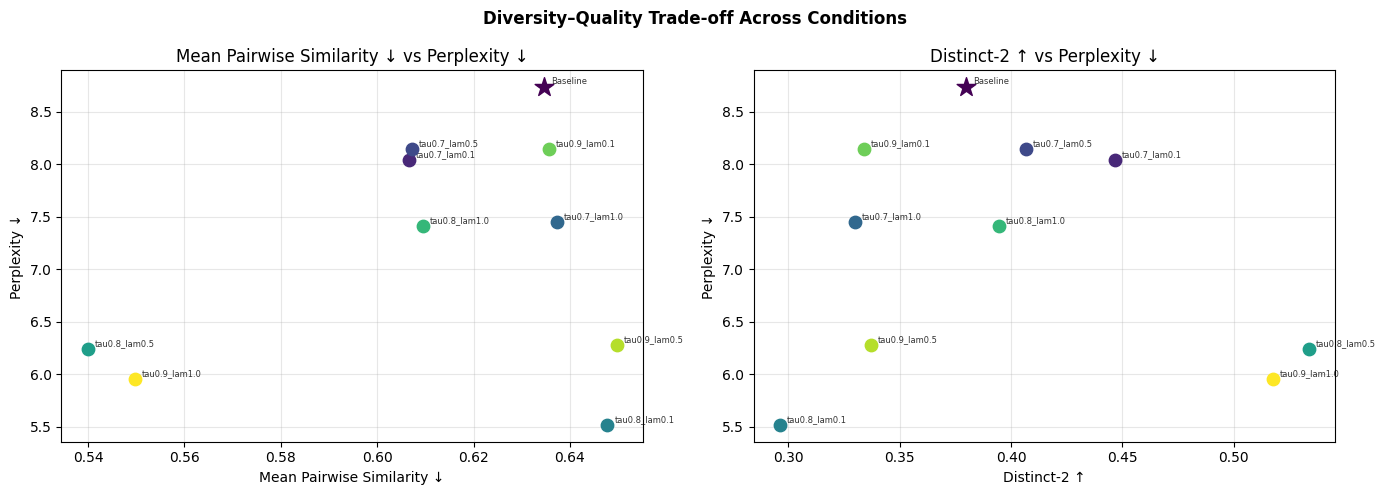

Figure 2 saved.


In [14]:
# ---- Figure 2: Diversity–Quality Trade-off Scatter ----

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Diversity–Quality Trade-off Across Conditions', fontsize=12, fontweight='bold')

colors = plt.cm.viridis(np.linspace(0, 1, len(all_results)))

for ax, (x_key, y_key, x_label, y_label, invert_x) in zip(
    axes,
    [
        ('mean_pairwise_sim', 'perplexity', 'Mean Pairwise Similarity ↓', 'Perplexity ↓', False),
        ('mean_distinct2', 'perplexity', 'Distinct-2 ↑', 'Perplexity ↓', False)
    ]
):
    for (key, res), color in zip(all_results.items(), colors):
        marker = '*' if key == 'Baseline' else 'o'
        size   = 200 if key == 'Baseline' else 80
        ax.scatter(res[x_key], res[y_key], color=color,
                   marker=marker, s=size, zorder=5,
                   label=res['label'])
        ax.annotate(res['label'].replace('CDFT_', ''),
                    (res[x_key], res[y_key]),
                    textcoords='offset points', xytext=(5, 2),
                    fontsize=6, alpha=0.8)

    ax.set_xlabel(x_label, fontsize=10)
    ax.set_ylabel(y_label, fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_title(f'{x_label} vs {y_label}')

plt.tight_layout()
plt.savefig('fig2_diversity_quality_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 2 saved.')

Best CDFT configuration: CDFT_tau0.8_lam0.5
  Pairwise sim  : 0.5400 (Baseline: 0.6346)
  Distinct-2    : 0.5339 (Baseline: 0.3797)
  Perplexity    : 6.24 (Baseline: 8.73)


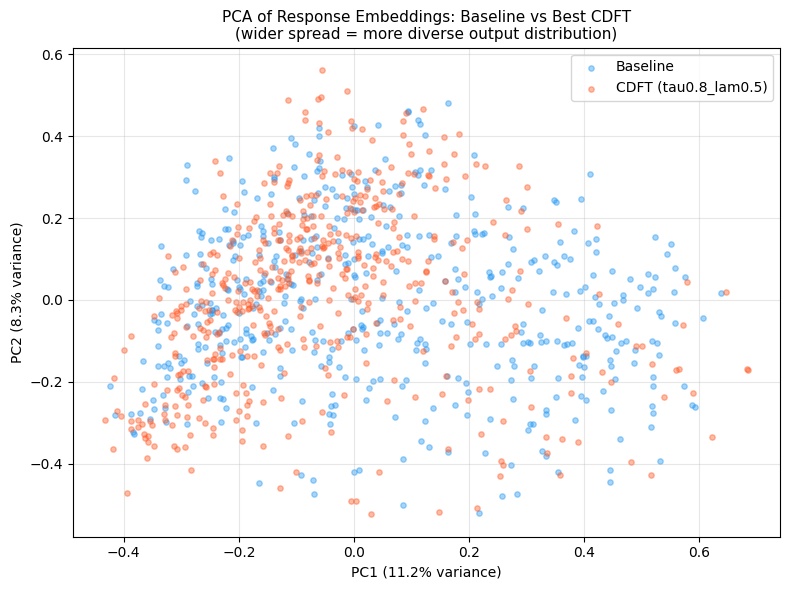

Figure 3 saved.


In [15]:
# ---- Figure 3: PCA of Response Embeddings (Baseline vs Best CDFT) ----

# Find best CDFT: lowest pairwise sim without perplexity > baseline_ppl * 1.3
best_key  = None
best_sim  = 999
for key, res in all_results.items():
    if key == 'Baseline':
        continue
    if res['perplexity'] <= baseline_ppl * 1.3:   # quality guard
        if res['mean_pairwise_sim'] < best_sim:
            best_sim = res['mean_pairwise_sim']
            best_key = key

print(f'Best CDFT configuration: {best_key}')
print(f'  Pairwise sim  : {all_results[best_key]["mean_pairwise_sim"]:.4f} '
      f'(Baseline: {baseline_sim:.4f})')
print(f'  Distinct-2    : {all_results[best_key]["mean_distinct2"]:.4f} '
      f'(Baseline: {baseline_d2:.4f})')
print(f'  Perplexity    : {all_results[best_key]["perplexity"]:.2f} '
      f'(Baseline: {baseline_ppl:.2f})')

# PCA visualisation
baseline_embs = all_results['Baseline']['all_embs']
cdft_embs     = all_results[best_key]['all_embs']

# Subsample for clarity
n_show = min(500, len(baseline_embs), len(cdft_embs))
idx_b  = np.random.choice(len(baseline_embs), n_show, replace=False)
idx_c  = np.random.choice(len(cdft_embs),     n_show, replace=False)

combined = np.vstack([baseline_embs[idx_b], cdft_embs[idx_c]])
pca = PCA(n_components=2, random_state=SEED)
coords = pca.fit_transform(combined)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(coords[:n_show, 0], coords[:n_show, 1],
           alpha=0.4, s=15, c='#2196F3', label='Baseline')
ax.scatter(coords[n_show:, 0], coords[n_show:, 1],
           alpha=0.4, s=15, c='#FF5722', label=f'CDFT ({best_key.replace("CDFT_","")})')
ax.set_title('PCA of Response Embeddings: Baseline vs Best CDFT\n'
             '(wider spread = more diverse output distribution)', fontsize=11)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig3_pca_embeddings.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 3 saved.')

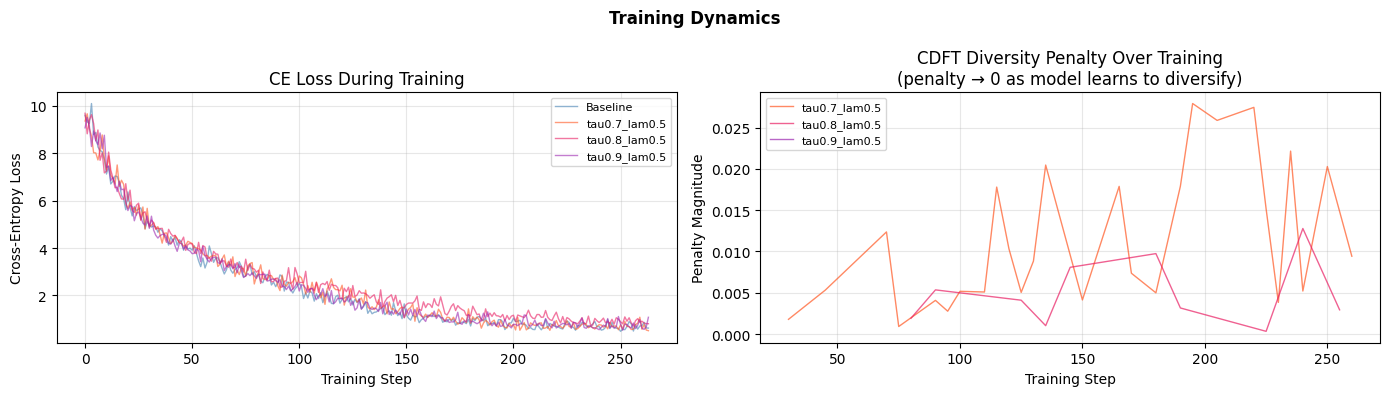

Figure 4 saved.


In [16]:
# ---- Figure 4: Training Loss Curves ----

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Training Dynamics', fontsize=12, fontweight='bold')

# Plot baseline CE loss
b_log = all_logs['Baseline']
b_steps = [r['step'] for r in b_log]
b_ce    = [r['ce_loss'] for r in b_log]

axes[0].plot(b_steps, b_ce, alpha=0.6, label='Baseline', color='steelblue', linewidth=1)

# Plot selected CDFT configs
selected_keys = [f'CDFT_tau{tau}_lam{lam}' for tau in TAU_VALUES for lam in [0.5]]
palette = ['#FF5722', '#E91E63', '#9C27B0']
for key, col in zip(selected_keys, palette):
    log  = all_logs[key]
    steps = [r['step'] for r in log]
    ce    = [r['ce_loss'] for r in log]
    axes[0].plot(steps, ce, alpha=0.6,
                 label=key.replace('CDFT_', ''), color=col, linewidth=1)

axes[0].set_xlabel('Training Step')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].set_title('CE Loss During Training')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Plot CDFT penalty magnitude
for key, col in zip(selected_keys, palette):
    log   = all_logs[key]
    steps = [r['step'] for r in log if r['penalty'] > 0]
    pens  = [r['penalty'] for r in log if r['penalty'] > 0]
    if steps:
        axes[1].plot(steps, pens, alpha=0.7,
                     label=key.replace('CDFT_', ''), color=col, linewidth=1)

axes[1].set_xlabel('Training Step')
axes[1].set_ylabel('Penalty Magnitude')
axes[1].set_title('CDFT Diversity Penalty Over Training\n(penalty → 0 as model learns to diversify)')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig4_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 4 saved.')

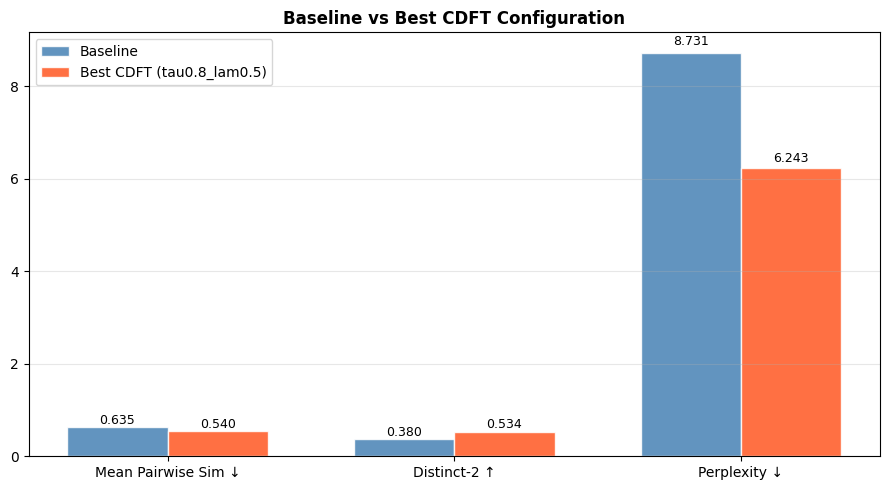

Figure 5 saved.


In [17]:
# ---- Figure 5: Bar chart comparing Baseline vs Best CDFT across all 3 metrics ----

metrics   = ['Mean Pairwise Sim ↓', 'Distinct-2 ↑', 'Perplexity ↓']
baseline_vals = [
    results_baseline['mean_pairwise_sim'],
    results_baseline['mean_distinct2'],
    results_baseline['perplexity']
]
cdft_vals = [
    all_results[best_key]['mean_pairwise_sim'],
    all_results[best_key]['mean_distinct2'],
    all_results[best_key]['perplexity']
]

x  = np.arange(len(metrics))
w  = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - w/2, baseline_vals, w, label='Baseline',
               color='steelblue', alpha=0.85, edgecolor='white')
bars2 = ax.bar(x + w/2, cdft_vals, w,
               label=f'Best CDFT ({best_key.replace("CDFT_","")})',
               color='#FF5722', alpha=0.85, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=10)
ax.set_title('Baseline vs Best CDFT Configuration', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, axis='y', alpha=0.3)

# Annotate bars with values
for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., h + h*0.01,
            f'{h:.3f}' if h < 100 else f'{h:.1f}',
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('fig5_baseline_vs_best_cdft.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 5 saved.')

## 9. Qualitative Examples

In [18]:
# Show side-by-side Baseline vs Best CDFT responses for 3 example prompts

example_prompts = eval_prompts[:3]

def generate_responses_for_display(model, prompt, n=5):
    model.eval()
    enc = tokenizer([prompt], return_tensors='pt',
                    truncation=True, max_length=MAX_INPUT_LEN).to(DEVICE)
    with torch.no_grad():
        out = model.generate(
            **enc, max_new_tokens=60, do_sample=True,
            top_p=0.9, temperature=1.0,
            pad_token_id=tokenizer.eos_token_id,
            num_return_sequences=n
        )
    new = out[:, enc['input_ids'].shape[1]:]
    return tokenizer.batch_decode(new, skip_special_tokens=True)

# Reload baseline and best CDFT for display
print('Reloading models for qualitative comparison...')
baseline_model_display, _ = train_model(condition='baseline')

best_tau = float(best_key.split('tau')[1].split('_')[0])
best_lam = float(best_key.split('lam')[1])
cdft_model_display, _ = train_model(condition='cdft', tau=best_tau, lam=best_lam)

print('\n' + '='*70)
print('QUALITATIVE COMPARISON: BASELINE vs BEST CDFT')
print('='*70)

for i, prompt in enumerate(example_prompts, 1):
    print(f'\n--- Prompt {i}: "{prompt[:80]}" ---')

    b_responses = generate_responses_for_display(baseline_model_display, prompt)
    c_responses = generate_responses_for_display(cdft_model_display, prompt)

    b_sim, _ = compute_pairwise_cosine(b_responses)
    c_sim, _ = compute_pairwise_cosine(c_responses)
    b_d2 = compute_distinct_n(b_responses)
    c_d2 = compute_distinct_n(c_responses)

    print(f'  BASELINE (sim={b_sim:.3f}, D2={b_d2:.3f}):')
    for j, r in enumerate(b_responses[:3], 1):
        print(f'    [{j}] {r[:100]}')

    print(f'  CDFT (sim={c_sim:.3f}, D2={c_d2:.3f}):')
    for j, r in enumerate(c_responses[:3], 1):
        print(f'    [{j}] {r[:100]}')

del baseline_model_display, cdft_model_display
torch.cuda.empty_cache()

Reloading models for qualitative comparison...

Training condition : BASELINE


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2-medium
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...23}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1/3:   0%|          | 0/88 [00:00<?, ?it/s]

  Epoch 1 | Mean CE: 4.8921 | Mean Penalty: 0.0000


...

  Epoch 1 | Mean CE: 4.8549 | Mean Penalty: 0.0000


Epoch 2/3:   0%|          | 0/88 [00:00<?, ?it/s]

  Epoch 2 | Mean CE: 1.6990 | Mean Penalty: 0.0002


Epoch 3/3:   0%|          | 0/88 [00:00<?, ?it/s]

  Epoch 3 | Mean CE: 0.7612 | Mean Penalty: 0.0006

QUALITATIVE COMPARISON: BASELINE vs BEST CDFT

--- Prompt 1: "How would you describe happiness to someone who has never felt it?" ---
  BASELINE (sim=0.700, D2=0.480):
    [1] 

What does it mean to you? How would you describe it to someone who has never felt it?

If you had 
    [2] 

What would you tell someone who is in a life of failure?

What would you tell someone who has neve
    [3]  How would you describe to someone who has never felt the most important thing in life? If you had n
  CDFT (sim=0.412, D2=0.584):
    [1] 

What does success mean to you? How would you describe it?

What you find the hardest thing you hav
    [2]  What you would describe the quality of a good relationship?

What would you describe the quality of
    [3] 

What you describe is the feeling that you have when you find out what makes a good friend? Do you 

--- Prompt 2: "How would you describe courage to a child?" ---
  BASELINE (sim=0.584, D2=0.524)





## 10. Final Result

In [19]:
print('\n===== EXPERIMENT COMPLETE =====')
print(f'Best CDFT config : {best_key}')
print(f'Pairwise sim     : {all_results[best_key]["mean_pairwise_sim"]:.4f} vs Baseline {baseline_sim:.4f}')
print(f'Distinct-2       : {all_results[best_key]["mean_distinct2"]:.4f} vs Baseline {baseline_d2:.4f}')
print(f'Perplexity       : {all_results[best_key]["perplexity"]:.2f} vs Baseline {baseline_ppl:.2f}')


===== EXPERIMENT COMPLETE =====
Best CDFT config : CDFT_tau0.8_lam0.5
Pairwise sim     : 0.5400 vs Baseline 0.6346
Distinct-2       : 0.5339 vs Baseline 0.3797
Perplexity       : 6.24 vs Baseline 8.73
